In [1]:
#| default_exp notebooks

# Notebook magics
> BPL magics and BPL output display for Jupyter and IPython


In [2]:
import html, json, re, basedpl
from importlib.resources import files
from fastcore.utils import *
from basedpl import BplError, symbols
from basedpl.ipython import load_ipython_extension as _load_help
from IPython.core.completer import context_matcher, SimpleCompletion
from IPython import get_ipython
from IPython.display import display, Javascript, HTML
from IPython.paths import get_ipython_dir


BPL adds `%bpl` and `%%bpl` magics to IPython. Both evaluate in `basedpl.bpl`, the workspace that Python code also uses. The magic renders the captured output and loads the language bar.

The line magic returns a native array or function. The cell magic displays what the BPL prompt would show, including implicit expression results.

In [3]:
from fastcore.test import *
from basedpl import Array, bpl
from IPython.utils.capture import capture_output
import numpy as np

## Rendering output

In [4]:
class AplOut(str):
    "APL output text, displayed in the BPL code font where HTML is available."
    def __repr__(self): return str(self)
    def _repr_html_(self): return f'<pre class="bpl_out">{html.escape(self.rstrip(chr(10)))}</pre>'


In [5]:
def display_events(events):
    "Display captured output in order, using MIME bundles for rich results."
    for e in events:
        data = e['data']
        if set(data) == {'text/plain'}: display(AplOut(data['text/plain']))
        else: display(data, raw=True)

`AplOut` preserves BPL spacing. Its HTML representation escapes the output before putting it in a `<pre>` element.

In [6]:
out = AplOut('1 < 2')
assert '&lt;' in out._repr_html_()
out

1 < 2

## The magics

The magics evaluate in `basedpl.bpl`, so Python calls through `bpl` share their workspace. The language bar and the font stylesheet, `fonts.css`, are loaded once for each magic instance.

In [7]:
class BPLMagic:
    "IPython BPL magics that evaluate in the workspace `basedpl.bpl`."
    def __init__(self): self._loaded = False


In [8]:
#| export
@patch
def _load(self:BPLMagic):
    if self._loaded: return
    js = files('basedpl')
    layout = (files('basedpl')/'layout.json').read_text()
    display(Javascript(f"{(js/'lb.js').read_text()}({json.dumps(symbols)}, {(js/'input.js').read_text()}, {layout})"))
    display(HTML(f"<style>{(js/'fonts.css').read_text()}</style>"))
    self._loaded = True

In [9]:
#| export
@patch
def bpl(self:BPLMagic, line, cell=None):
    "Evaluate a line as a native value or display a cell as a BPL session."
    self._load()
    code = line if cell is None else cell.rstrip()
    show = not (cell is not None and code.endswith(';'))
    if not show: code = code[:-1]
    output = []
    try:
        result = basedpl.bpl(code, 'explicit' if cell is None else 'repl')
        output = result.events
    except (BplError, KeyboardInterrupt) as e:
        output = getattr(e, 'events', [])
        raise
    finally:
        if show: display_events(output)
    if cell is None: return result.value

Cell output comes from `bpl(code, 'repl')`, which includes implicit expression results. Line output comes from `bpl(code, 'explicit')`, which captures explicit output and returns native values. A trailing `;` suppresses all cell display without skipping execution. Output produced before an error is displayed before the error is raised.

Tab completes user and system names in BPL input. Completion reads the workspace without evaluating anything.

In [10]:
#| export
@patch
@context_matcher(identifier='basedpl.names')
def complete(self:BPLMagic, context):
    "Complete visible BPL names in line and cell magics."
    empty = dict(completions=[])
    before = '\n'.join(context.full_text.split('\n')[:context.cursor_line] + [context.text_until_cursor])
    if m := re.match(r'%%bpl[^\S\n]*\n', before): code = before[m.end():]
    elif m := re.match(r'\s*(?:\w+\s*=\s*)?%bpl\s+', context.text_until_cursor): code = context.text_until_cursor[m.end():]
    else: return empty
    if any(m.end() == len(code) for m in re.finditer(r'''"(?:[^"]|"")*(?:"|$)|'(?:[^\n]'?|$)|⍝[^\n]*''', code)): return empty
    start = len(code)
    glyphs = {s['glyph'] for s in symbols} - {'•'}
    while start and code[start-1] not in glyphs and (code[start-1].isalnum() or code[start-1] in '_∆⍙•'): start -= 1
    prefix = code[start:]
    if not prefix: return empty
    return dict(completions=[SimpleCompletion(n, type='BPL name') for n in basedpl.bpl.complete(prefix)],
        matched_fragment=prefix, suppress=True)

In [11]:
def create_magic(shell=None):
    "Register line and cell magics with `shell`. They evaluate in `basedpl.bpl`."
    if shell is None: shell = get_ipython()
    magic = BPLMagic()
    shell.register_magic_function(magic.bpl, 'line_cell', 'bpl')
    matchers = shell.Completer.custom_matchers
    matchers[:] = [m for m in matchers if getattr(m, 'matcher_identifier', None) != 'basedpl.names']
    matchers.append(magic.complete)
    _load_help(shell)
    return magic


In [12]:
#| hide
magic = create_magic()
magic.bpl('')

Javascript(// Based on Adám Brudzewsky's APL language bar: https://abrudz.github.io/lb
// MIT License, Copyright (c) 2011-2020 Nikolay G. Nikolov and Adam Brudzevski.
// BPL name completion, editor adapters, dark mode and overlay layout by Jeremy Howard.
((symbols, input, layout) => {
    const d = document;
    if (d.querySelector('.ngn_lb') || d.querySelector('meta[name=generator][content^=quarto]')) return;

    const {inCode, bplStart, entry, press, reset} = input(symbols, layout);
    const shortcuts = new Map(symbols.map(({glyph, shortcut}) => [glyph, shortcut]));
    let leftAlt = false, rightAlt = false;

    function textareaRect(t) {
        const mirror = d.createElement('div'), caret = d.createElement('span'), css = getComputedStyle(t), rect = t.getBoundingClientRect();
        for (const p of ['font', 'lineHeight', 'letterSpacing', 'padding', 'border', 'boxSizing', 'width', 'tabSize']) mirror.style[p] = css[p];
        Object.assign(mirror.style, {position: 'fixed', visibi

HTML(<style>/* Code fonts for the magics and the docs. scripts/prep.py copies this file to nbs/fonts.css, so edit it here. */
:root { --bpl-font: SAX2; --apl-font: BQN386; }
@font-face { font-family: SAX2; src: local("SAX2"), url("https://cdn.jsdelivr.net/gh/abrudz/SAX2@master/SAX2.ttf") format("truetype"); }
@font-face { font-family: BQN386; src: local("BQN386"), url("https://cdn.jsdelivr.net/gh/dzaima/BQN386@master/BQN386.woff2") format("woff2"); }
.bpl_out { font-family: var(--bpl-font), monospace !important; line-height: 1.05 !important; }
</style>)

The cell magic displays each expression. Assignments remain silent.

In [13]:
%%bpl
m←2 3⍴⍳6
m×10

0 10 20
30 40 50

The line magic returns a native `basedpl.Array`. Use `.np` or `.py` for conversion. Comments are parsed by BPL, including `⍝` inside quoted strings.

In [14]:
z = %bpl m ⍝ a matrix
test_is(type(z), Array)
np.testing.assert_array_equal(z.np, [[0, 1, 2], [3, 4, 5]])
test_eq(magic.bpl('"a⍝b" ⍝ comment').py, 'a⍝b')
z

0 1 2
3 4 5

Python values bound through `bpl` are visible to the magics. Python integers stay exact.

In [15]:
bpl(x=np.arange(1, 4))
value = %bpl +/x
test_eq(value.py, 6)
test_is(type(value.py), int)
value

6ₓ

BPL's display commands also work in a cell.

In [16]:
%%bpl
]Display [[1 2] "ab"]

┌→───────────┐
│ ┌→──┐ ┌→─┐ │
│ │1 2│ │ab│ │
│ └~──┘ └──┘ │
└∊───────────┘

A suppressed cell still updates the workspace.

In [17]:
%%bpl
quiet←7;


In [18]:
#| hide
with capture_output() as cap: magic.bpl('', 'quiet←9 ⋄ ⎕←quiet;')
test_eq(len(cap.outputs), 0)
test_eq(magic.bpl('quiet').py, 9)
with capture_output() as cap: magic.bpl('', 'quiet ⋄ quiet+1')
assert '9' in cap.outputs[0].data['text/html'] and '10' in cap.outputs[1].data['text/html']

SVG elements and custom MIME renderers display in cell magics and as Python values.

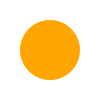

In [19]:
%%bpl
circle←•element "circle"
•svg ["cx":50 "cy":50 "r":30 "fill":"orange"] circle ""

## Names and help

Use `]help name` for help and `]help name -source` for source, in either magic. Leading definition comments supply help. Inspection leaves the function uncalled.

In [20]:
%%bpl
double←{⍝ Double the argument
⎕←"called" ⋄ ⍵×2}

In [21]:
with capture_output() as cap: magic.bpl(']help double')
assert 'Double the argument' in cap.outputs[0].data['text/markdown']
with capture_output() as cap: magic.bpl('', ']help double -source')
assert '⎕←"called"' in cap.outputs[0].data['text/markdown']
test_eq(len(cap.outputs), 1)

Completion follows the magic's workspace, including names defined after registration. Quoted text and comments stay literal.

In [22]:
from IPython.core.completer import provisionalcompleter

In [23]:
shell = get_ipython()
for text, expected in [('%bpl dou', 'double'), ('v = %bpl dou', 'double'), ('%%bpl\n1+•sr', '•src'), ("%%bpl\n''' dou", 'double')]:
    with provisionalcompleter(): matches = list(shell.Completer.completions(text, len(text)))
    assert expected in [m.text for m in matches]
for text in ['%%bpl\n"dou', '%%bpl\n⍝ dou', 'ordinary_python']:
    with provisionalcompleter(): matches = list(shell.Completer.completions(text, len(text)))
    assert not any(m.type == 'BPL name' for m in matches)

## Errors and workspace state

Errors retain source locations and leave completed assignments in the workspace. Incomplete input raises a syntax error and leaves the workspace unchanged.

In [24]:
with capture_output() as cap: test_fail(lambda: magic.bpl('', '⎕←42 ⋄ 1÷"a"'), contains='DOMAIN ERROR')
assert '42' in cap.outputs[0].data['text/html']
test_fail(lambda: magic.bpl('', '{⍵+1'), contains='SYNTAX ERROR')
test_eq(magic.bpl('quiet').py, 9)

Set `bpl.timeout` to a per-evaluation deadline in seconds. Ctrl-C interrupts the evaluation. Output captured before cancellation is displayed. The workspace keeps its names after cancellation. Native-library calls and individual BigInt operations can delay cancellation.

## Installation

`%load_ext basedpl.notebooks` registers the magics in the current kernel. `bpl-install-magic` adds the extension to the default IPython profile. Registration does not start a BPL worker.

In [25]:
def load_ipython_extension(ipython):
    "Register the BPL magics when IPython loads this extension."
    create_magic(shell=ipython)

In [26]:
def create_ipython_config():
    "Called by `bpl-install-magic` to install magic"
    ipython_dir = Path(get_ipython_dir())
    cf = ipython_dir/'profile_default'/'ipython_config.py'
    cf.parent.mkdir(parents=True, exist_ok=True)
    if cf.exists() and 'basedpl.notebooks' in cf.read_text(): return print('BPL magics already installed!')
    with cf.open(mode='a') as f: f.write("\nc.InteractiveShellApp.extensions.append('basedpl.notebooks')\n\n")
    print(f"Jupyter config updated at {cf}")

## Symbol input

The browser input method uses BPL's symbol names and aliases. It is active in `%%bpl` and `%%apl` cells, `%bpl` lines and Monaco editors configured for BPL. Matching prefers exact names, then prefixes, then abbreviations. A unique match is accepted with Tab or a delimiter. Enter accepts it before the notebook's usual newline or execution action. Ambiguous matches remain unchanged and appear in a clickable list.

Strings, comments and pasted text are not expanded. Cursor movement and Escape cancel automatic expansion. The clickable language bar can still insert literal glyphs.

Hold **left Alt/Option** to type glyphs using the keys in the [glyph reference](glyphs.qmd#typing-glyphs): Alt-h `←`, Alt-m `×` and Alt-u `÷`. Some glyphs take a second key, as Alt-a then `_` gives `⍶`, and Alt-6 then a digit gives a superscript. Alt keys insert literal glyphs, including inside BPL strings and comments. Right Option keeps its native keyboard behavior. The glyph map is shared with the BPL REPL.

In [ ]:
#|hide
#|eval: false
from nbdev.doclinks import nbdev_export
nbdev_export()